In [1]:
import pandas as pd
file_path = r"C:\Users\Prasanth Rajaram\Downloads\cover_type (1).csv"
df = pd.read_csv(file_path)
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [2]:
#View the first 5 rows
print("\n--- FIRST 5 ROWS ---")
print(df.head())


--- FIRST 5 ROWS ---
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2            

In [3]:
#View Dataset Information
print("\n--- DATASET INFO ---")
df.info()


--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area  

In [4]:
#Statistical Summary
print("\n--- STATISTICAL SUMMARY ---")
print(df.describe())


--- STATISTICAL SUMMARY ---
           Elevation         Aspect          Slope  \
count  145890.000000  145890.000000  145890.000000   
mean     2874.458949     141.127418      11.925574   
std       210.801279     107.719296       6.319326   
min      1863.000000       0.000000       0.000000   
25%      2747.000000      54.000000       7.000000   
50%      2909.000000     108.000000      11.000000   
75%      3004.000000     217.000000      15.000000   
max      3849.000000     360.000000      61.000000   

       Horizontal_Distance_To_Hydrology  Vertical_Distance_To_Hydrology  \
count                     145890.000000                   145890.000000   
mean                         251.824738                       34.554322   
std                          192.473899                       41.215776   
min                            0.000000                     -146.000000   
25%                           95.000000                        7.000000   
50%                          212.0

In [5]:
#Categorical Variable Distribution
print("\n--- DISTRIBUTION OF COVER TYPE ---")
print(df['Cover_Type'].value_counts())


--- DISTRIBUTION OF COVER TYPE ---
Cover_Type
Lodgepole Pine       103071
Spruce/Fir            31110
Aspen                  3069
Krummholz              2160
Ponderosa Pine         2160
Douglas-fir            2160
Cottonwood/Willow      2160
Name: count, dtype: int64


In [6]:
#Categorical Variable Distribution (Class Imbalance)
print("\n--- CLASS DISTRIBUTION IMBALANCE (Percentages) ---")
print(df['Cover_Type'].value_counts(normalize=True) * 100)


--- CLASS DISTRIBUTION IMBALANCE (Percentages) ---
Cover_Type
Lodgepole Pine       70.649805
Spruce/Fir           21.324285
Aspen                 2.103640
Krummholz             1.480568
Ponderosa Pine        1.480568
Douglas-fir           1.480568
Cottonwood/Willow     1.480568
Name: proportion, dtype: float64


In [7]:
#Check for Missing Values
print("\n--- MISSING VALUES PER COLUMN ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found in the dataset.")



--- MISSING VALUES PER COLUMN ---
No missing values found in the dataset.


In [8]:
# Missing Value Imputation
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# Fill numbers with median, fill categories with mode
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print("\nMissing values imputed successfully!")


Missing values imputed successfully!


In [9]:
# Simple Outlier Handling (IQR Method)
cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 
        'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 
        'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']

for col in cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    df[col] = df[col].clip(lower=Q1 - 1.5 * (Q3 - Q1), upper=Q3 + 1.5 * (Q3 - Q1))

print("\nOutliers capped successfully using IQR!")



Outliers capped successfully using IQR!


In [10]:
#Skewness Fix using log1p
import numpy as np
for col in cols:
    df[col] = np.log1p(df[col] - df[col].min() + 1)
df[col]

0         8.745284
1         8.736650
2         8.719807
3         8.734399
4         8.728102
            ...   
145885    7.375882
145886    7.361375
145887    7.347300
145888    7.333023
145889    7.318540
Name: Horizontal_Distance_To_Fire_Points, Length: 145890, dtype: float64

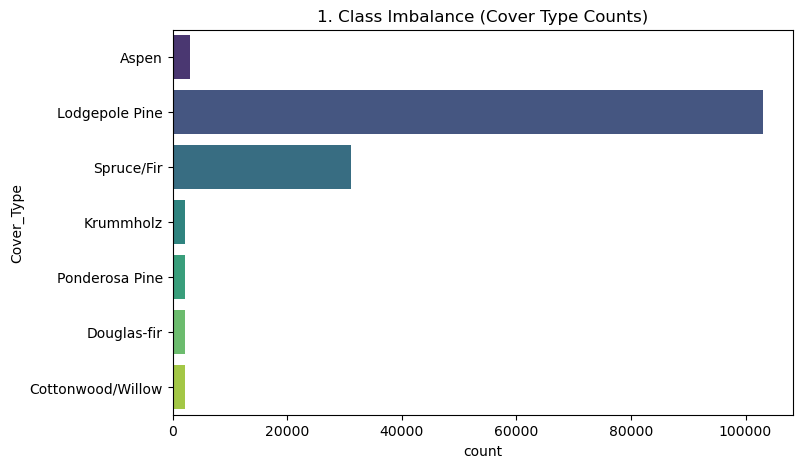

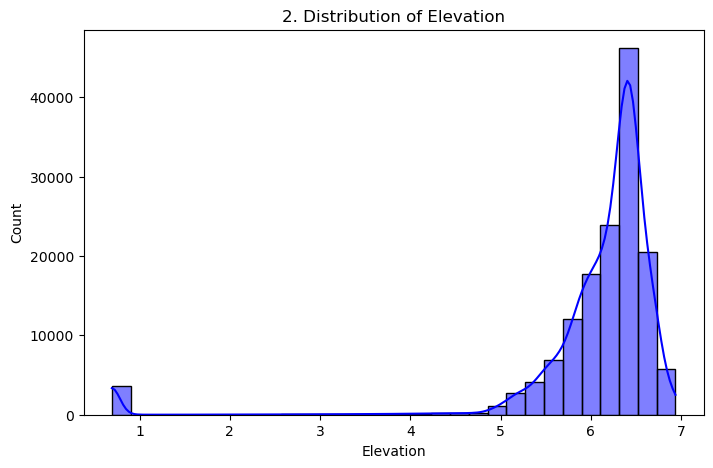

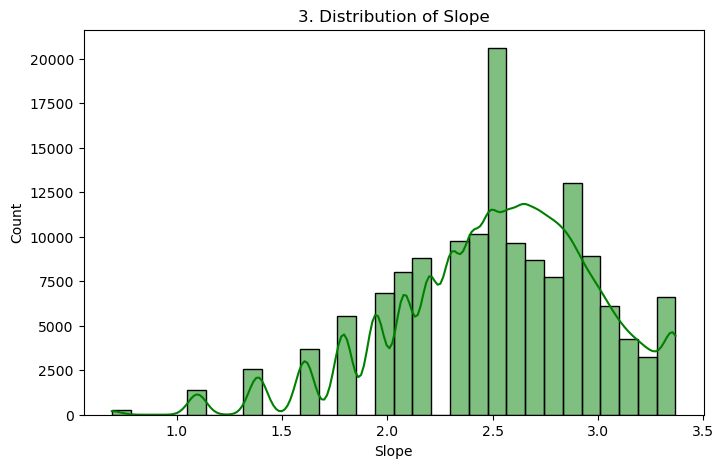

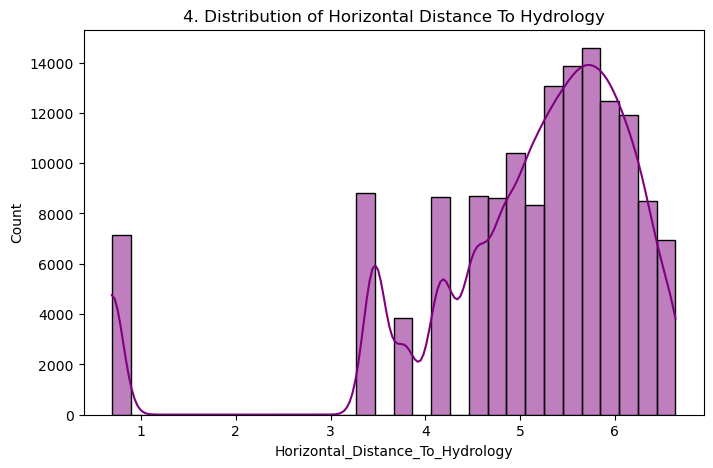

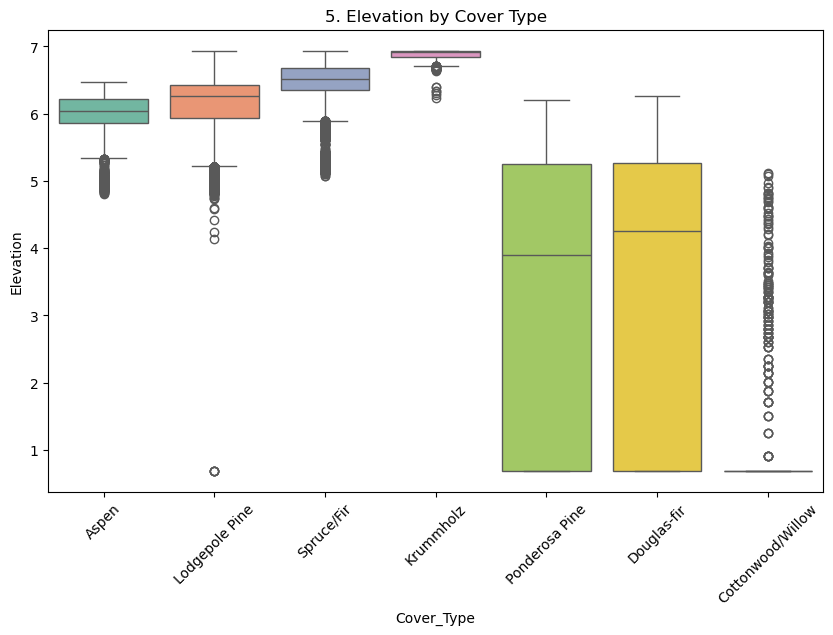

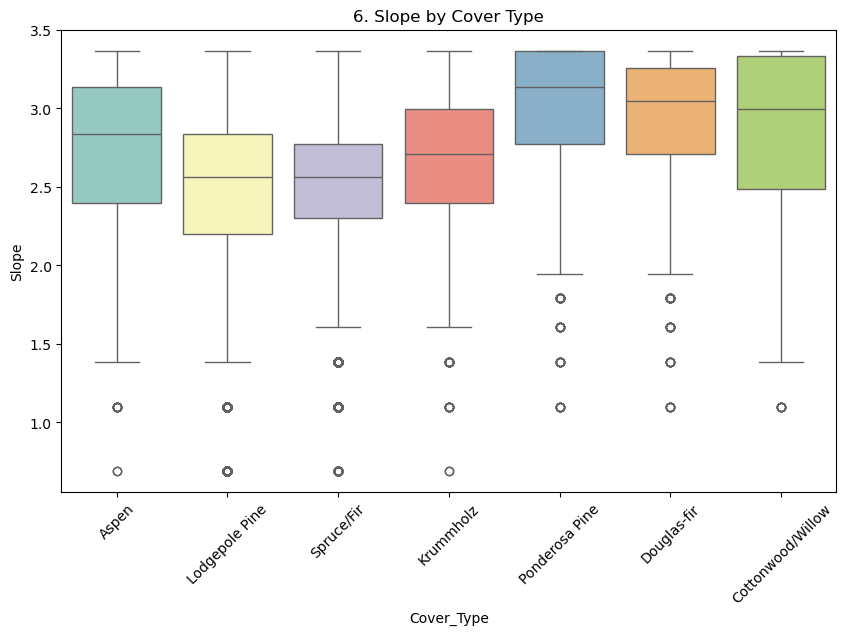

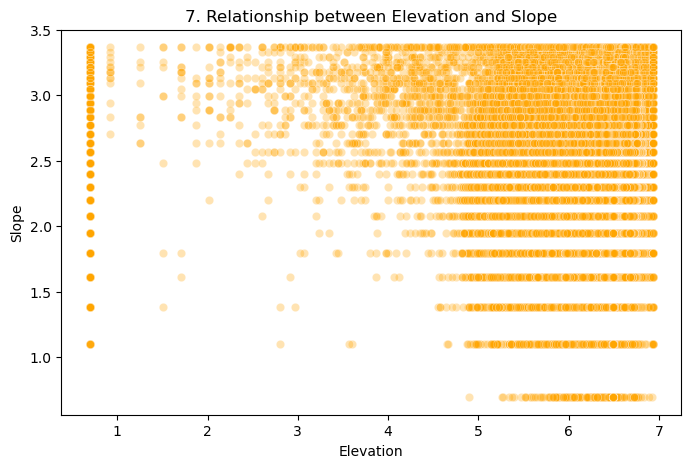

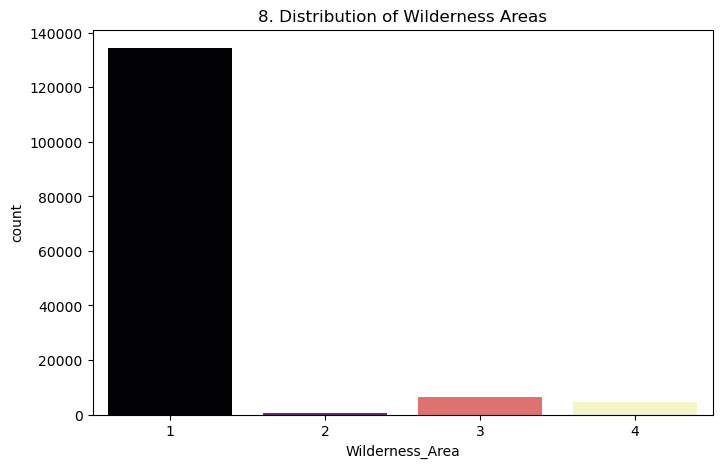

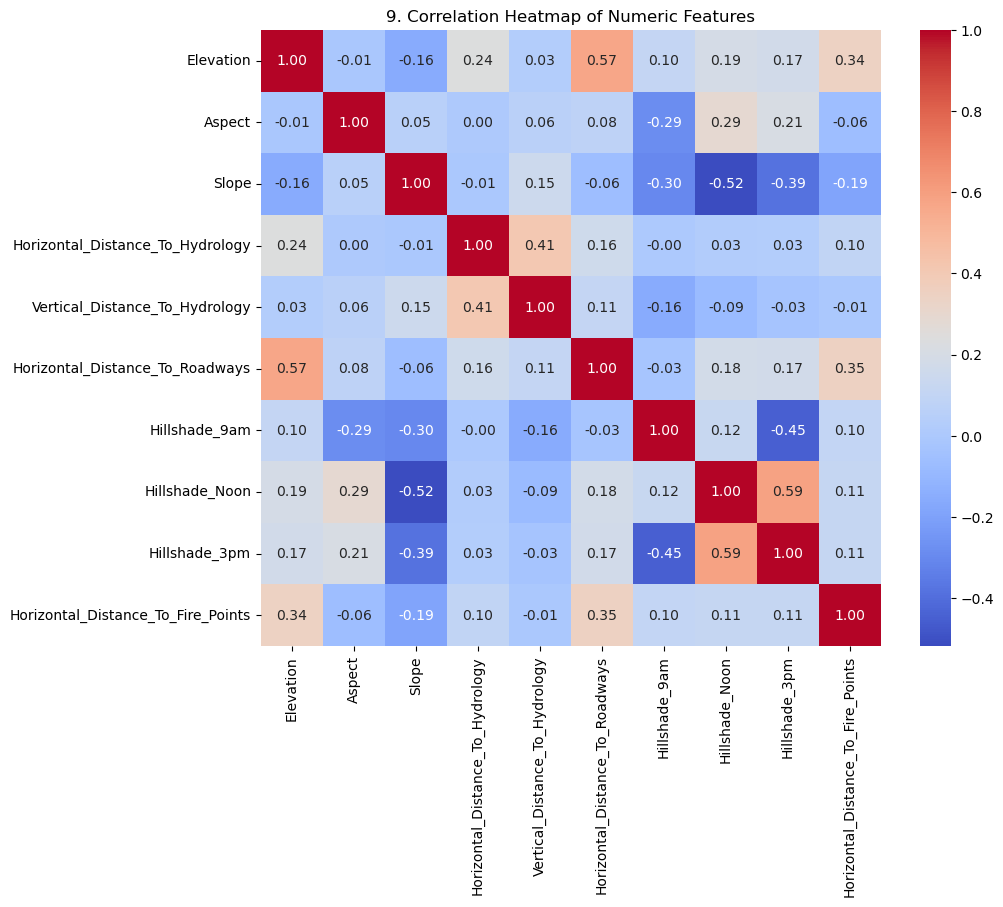

Fitting Baseline Model for Feature Importances... Please wait.


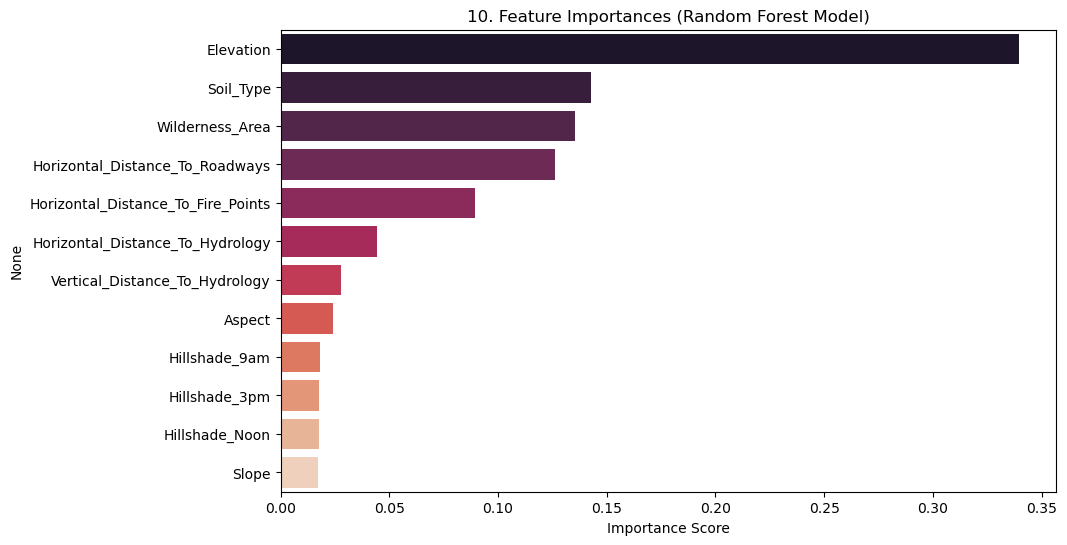

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
# -- Plot 1: Class Imbalance (Countplot) --
plt.figure(figsize=(8,5))
sns.countplot(data=df, y='Cover_Type', hue='Cover_Type', legend=False, palette='viridis')
plt.title("1. Class Imbalance (Cover Type Counts)")
plt.show()

# -- Plot 2: Univariate (Histogram of Elevation) --
plt.figure(figsize=(8,5))
sns.histplot(df['Elevation'], bins=30, kde=True, color='blue')
plt.title("2. Distribution of Elevation")
plt.show()

# -- Plot 3: Univariate (Histogram of Slope) --
plt.figure(figsize=(8,5))
sns.histplot(df['Slope'], bins=30, kde=True, color='green')
plt.title("3. Distribution of Slope")
plt.show()

# -- Plot 4: Univariate (Histogram of Distance to Hydrology) --
plt.figure(figsize=(8,5))
sns.histplot(df['Horizontal_Distance_To_Hydrology'], bins=30, kde=True, color='purple')
plt.title("4. Distribution of Horizontal Distance To Hydrology")
plt.show()

# -- Plot 5: Bivariate (Boxplot of Elevation vs Cover_Type) --
plt.figure(figsize=(10,6))
sns.boxplot(x='Cover_Type', y='Elevation', data=df, hue='Cover_Type', legend=False, palette='Set2')
plt.title("5. Elevation by Cover Type")
plt.xticks(rotation=45)
plt.show()

# -- Plot 6: Bivariate (Boxplot of Slope vs Cover_Type) --
plt.figure(figsize=(10,6))
sns.boxplot(x='Cover_Type', y='Slope', data=df, hue='Cover_Type', legend=False, palette='Set3')
plt.title("6. Slope by Cover Type")
plt.xticks(rotation=45)
plt.show()

# -- Plot 7: Bivariate (Scatterplot of Elevation vs Slope) --
plt.figure(figsize=(8,5))
sns.scatterplot(x='Elevation', y='Slope', data=df, alpha=0.3, color='orange')
plt.title("7. Relationship between Elevation and Slope")
plt.show()

# -- Plot 8: Univariate (Countplot of Wilderness Area) --
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Wilderness_Area', hue='Wilderness_Area', legend=False, palette='magma')
plt.title("8. Distribution of Wilderness Areas")
plt.show()

# -- Plot 9: Correlation Heatmap --
plt.figure(figsize=(10,8))
corr = df[cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("9. Correlation Heatmap of Numeric Features")
plt.show()

# -- Plot 10: Baseline Model Feature Importances --
print("Fitting Baseline Model for Feature Importances... Please wait.")
le = LabelEncoder()
y = le.fit_transform(df['Cover_Type'])
X = df.drop(columns=['Cover_Type'])

model = RandomForestClassifier(n_estimators=20, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X, y)

plt.figure(figsize=(10,6))
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, legend=False, palette='rocket')
plt.title("10. Feature Importances (Random Forest Model)")
plt.xlabel("Importance Score")
plt.show()


In [12]:
# -- Categorical Encoding & Saving --
import joblib

print("\n--- ENCODING AND SAVING ENCODER ---")
le = LabelEncoder()
df['Cover_Type'] = le.fit_transform(df['Cover_Type'])

# Save the encoder for future inference
joblib.dump(le, 'cover_type_encoder.pkl')
print("Saved cover_type_encoder.pkl for inference!")

# Define Features and Target
X = df.drop(columns=['Cover_Type'])
y = df['Cover_Type']


--- ENCODING AND SAVING ENCODER ---
Saved cover_type_encoder.pkl for inference!


In [13]:
# -- Balance Class Distribution using SMOTE --
from imblearn.over_sampling import SMOTE
print("\n--- BALANCING CLASS DISTRIBUTION WITH SMOTE ---")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print(f"Original dataset shape: {X.shape}")
print(f"Resampled dataset shape: {X_resampled.shape}")


--- BALANCING CLASS DISTRIBUTION WITH SMOTE ---
Original dataset shape: (145890, 12)
Resampled dataset shape: (721497, 12)


In [14]:
# -- Feature Selection --
print("\n--- FEATURE SELECTION ---")
# 1. Drop Low-Variance Features (variance < 0.01)
low_var_cols = X_resampled.columns[X_resampled.var() < 0.01]
X_resampled = X_resampled.drop(columns=low_var_cols)
print(f"Dropped {len(low_var_cols)} low-variance features.")
# 2. Select Top 15 Features based on Model Importances
selected_features = importances[importances.index.isin(X_resampled.columns)].head(15).index.tolist()
X_final = X_resampled[selected_features]
print(f"Selected Top {len(selected_features)} features:\n{selected_features}")
print(f"\nFinal Optimized Feature Set Shape: {X_final.shape}")


--- FEATURE SELECTION ---
Dropped 0 low-variance features.
Selected Top 12 features:
['Elevation', 'Soil_Type', 'Wilderness_Area', 'Horizontal_Distance_To_Roadways', 'Horizontal_Distance_To_Fire_Points', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Aspect', 'Hillshade_9am', 'Hillshade_3pm', 'Hillshade_Noon', 'Slope']

Final Optimized Feature Set Shape: (721497, 12)


In [20]:
 #-- Model Building and Evaluation --
%pip install xgboost
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

print("\n--- MODEL BUILDING AND EVALUATION ---")
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_final, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Scale features (important for Logistic Regression and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1),
    "K-Nearest Neighbors": KNeighborsClassifier(n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, n_jobs=-1)
}

# Evaluate models
results = {}
for name, clf in models.items():
    print(f"\nTraining and Evaluating: {name}...")
    # Train using scaled data
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"[{name}] Accuracy: {acc:.4f}")
    print(f"[{name}] Classification Report:\n{classification_report(y_test, y_pred)}")
    print(f"[{name}] Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

# Compare Accuracies
print("\n--- MODEL COMPARISON ---")
print("Accuracy Leaderboard:")
for name, acc in sorted(results.items(), key=lambda item: item[1], reverse=True):
    print(f"{name}: {acc:.4f}")

Note: you may need to restart the kernel to use updated packages.

--- MODEL BUILDING AND EVALUATION ---

Training and Evaluating: Random Forest...
[Random Forest] Accuracy: 0.9915
[Random Forest] Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20614
           1       1.00      1.00      1.00     20614
           2       1.00      1.00      1.00     20614
           3       1.00      1.00      1.00     20615
           4       0.98      0.97      0.97     20614
           5       1.00      1.00      1.00     20614
           6       0.97      0.98      0.98     20615

    accuracy                           0.99    144300
   macro avg       0.99      0.99      0.99    144300
weighted avg       0.99      0.99      0.99    144300

[Random Forest] Confusion Matrix:
[[20593     0     0     0    12     7     2]
 [    0 20605     4     0     0     5     0]
 [    0     8 20581     0     0    25     0]
 [    0     0 

In [21]:
# -- Hyperparameter Tuning on Entire Data --
from sklearn.model_selection import RandomizedSearchCV

print("\n" + "="*50)
print("--- HYPERPARAMETER TUNING ON ENTIRE DATASET ---")
print("="*50)

# Random Forest was identified as the best model
rf_model = models["Random Forest"]

# Define the hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Scale the entire final dataset (so we have a scaler for deployment)
final_scaler = StandardScaler()
X_final_scaled_all = final_scaler.fit_transform(X_final)

# We use cv=3 and n_iter=5 for faster tuning on the whole dataset
random_search = RandomizedSearchCV(
    estimator=rf_model, 
    param_distributions=param_grid, 
    n_iter=5,  # Tries 5 random combinations
    cv=3,      # 3-fold cross validation
    scoring='accuracy', 
    n_jobs=1,  # FIXED: Set to 1 to avoid thread deadlock with Random Forest's n_jobs=-1 
    random_state=42,
    verbose=2
)

print("\nStarting RandomizedSearchCV for Random Forest on the ENTIRE dataset...")
print("WARNING: This will perform 15 fits (5 candidates * 3 folds) and may take a few minutes.")

# Fit the random search to the ENTIRE data
random_search.fit(X_final_scaled_all, y_resampled)

print("\n--- TUNING RESULTS ---")
print(f"Best Parameters Found: {random_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {random_search.best_score_:.4f}")

# The best estimator is automatically retrained on the entire dataset by RandomizedSearchCV
best_tuned_rf = random_search.best_estimator_

# -- Saving the Best Model and Scaler --
print("\n--- SAVING MODEL AND SCALER ---")
model_filename = 'best_model.pkl'
scaler_filename = 'scaler.pkl'

joblib.dump(best_tuned_rf, model_filename)
joblib.dump(final_scaler, scaler_filename)

print(f"Saved the best-performing trained model as '{model_filename}' for deployment!")
print(f"Saved the scaler as '{scaler_filename}' for deployment!")



--- HYPERPARAMETER TUNING ON ENTIRE DATASET ---

Starting RandomizedSearchCV for Random Forest on the ENTIRE dataset...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END max_depth=30, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time= 3.1min
[CV] END max_depth=30, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time= 3.1min
[CV] END max_depth=30, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time= 3.1min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 1.2min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 1.1min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 1.3min
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 1.2min
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 1.1min
[CV] END ma